# Experiement 2 - REAL




## 1. Imports

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from scipy.stats import wilcoxon, ttest_rel, rankdata

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 2. Configuration



In [26]:
# ── Data: your Exp6.1 static-room recordings (real RPLIDAR CSVs) ───────────────
# Put the file name(s) / pattern for the Exp6.1 records here:
DATA_FILES = sorted(Path(".").glob("*.csv"))   # e.g. Path(".").glob("exp61_*.csv")

# ── DBSCAN / kernel (SAME as Exp6/7/8) ────────────────────────────────────────
FIXED_EPS        = 0.12
FIXED_MIN_SAMPS  = 3
ALPHA_MIN = 0.30
ALPHA_MAX = 0.70
TAU       = 1.5
BETA      = 0.0
R_THETA   = 4.0
S_OBJ_M   = 0.40

MIN_RANGE_MM = 100
MAX_RANGE_MM = 8000
SURFACE_MARGIN_M = 0.12

# ── Sensor frame: scans are sensor-centric polar, so the sensor is the origin ──
SENSOR = {"x": 0.0, "y": 0.0, "yaw": 0.0}

# ── OPTIONAL: real object layout for ARI (positions in metres, relative to sensor)
# Fill this in if you know where your objects were. Examples:
#   {"type": "rect",   "x": 1.2, "y": 0.0, "sx": 0.30, "sy": 0.40}
#   {"type": "circle", "x": 0.8, "y": 0.6, "r": 0.15}
OBJECTS = [
    # {"type": "rect", "x": ?, "y": ?, "sx": ?, "sy": ?},
]
COMPUTE_ARI = len(OBJECTS) > 0
print("ARI mode:", "ON (objects provided)" if COMPUTE_ARI else "OFF (internal metrics only)")
print("Data files:", [f.name for f in DATA_FILES])


ARI mode: OFF (internal metrics only)
Data files: ['2025.01.01_LargeRoom_BoxesInLine_03.csv', '2025.01.01_LargeRoom_Empty_01.csv', '2025.01.01_LargeRoom_Empty_02.csv', '2025.01.01_MedRoom_Empty_01.csv', '2025.01.01_MiddleRoom_Empty_01.csv', '2025.01.01_SmallRoom_Empty_01.csv', '2025.01.01_SmallRoom_Pos_01.csv', '2025.03.02_1_roombox2.csv', '2025.03.02_2_room6boxnoise.csv', 'exp2_summary_table.csv', 'exp61_results.csv', 'exp61_stats.csv']


## 3. Kernel — Single Source of Truth (identical to Exp6/7/8)

In [27]:
def sigmoid(z): return 1.0 / (1.0 + np.exp(-z))

def r0_from_device(s_obj_m, dtheta_deg, min_pts=FIXED_MIN_SAMPS):
    return s_obj_m / (min_pts * np.deg2rad(dtheta_deg))

def alpha_schedule(r_bar_m, r0_m):
    return ALPHA_MIN + (ALPHA_MAX - ALPHA_MIN) * sigmoid((r0_m - r_bar_m) / TAU)

def prepare_points_euclidean(df):
    r = df["distance_mm"].values / 1000.0
    th = np.deg2rad(df["angle_deg"].values)
    return np.column_stack([r * np.cos(th), r * np.sin(th)])

def prepare_points_kernel(df, r_bar_m, r0_m):
    r = df["distance_mm"].values / 1000.0
    th = np.deg2rad(df["angle_deg"].values)
    alpha = alpha_schedule(r_bar_m, r0_m)
    rp = r ** alpha
    thp = th * (1.0 + BETA * max(0.0, r_bar_m - R_THETA))
    return np.column_stack([rp * np.cos(thp), rp * np.sin(thp)]), alpha

def run_dbscan(points):
    return DBSCAN(eps=FIXED_EPS, min_samples=FIXED_MIN_SAMPS).fit_predict(points)

def n_clusters(l): return len(set(l)) - (1 if -1 in l else 0)
def noise_pct(l):  return 100.0 * np.sum(l == -1) / len(l)

def estimate_dtheta(df):
    diffs = []
    for _, g in df.groupby("timestamp"):
        a = np.sort(g["angle_deg"].values); d = np.diff(a); d = d[(d > 0) & (d < 5)]
        diffs.extend(d)
    return float(np.median(diffs)) if diffs else 1.0

def internal_metrics(points_euclid, labels):
    """Silhouette + Davies-Bouldin on REAL coords (fair for both methods)."""
    mask = labels != -1
    if mask.sum() < 3 or len(set(labels[mask])) < 2:
        return np.nan, np.nan
    try:
        return (silhouette_score(points_euclid[mask], labels[mask]),
                davies_bouldin_score(points_euclid[mask], labels[mask]))
    except Exception:
        return np.nan, np.nan


## 4. Optional Ground Truth from `OBJECTS` (for ARI)



In [28]:
def _in_rect(px, py, cx, cy, sx, sy, m):
    return (np.abs(px - cx) <= sx / 2 + m) & (np.abs(py - cy) <= sy / 2 + m)

def _in_circ(px, py, cx, cy, r, m):
    return (px - cx) ** 2 + (py - cy) ** 2 <= (r + m) ** 2

def ground_truth_labels(df, margin=SURFACE_MARGIN_M):
    r = df["distance_mm"].values / 1000.0
    th = np.deg2rad(df["angle_deg"].values) + SENSOR["yaw"]
    px = SENSOR["x"] + r * np.cos(th)
    py = SENSOR["y"] + r * np.sin(th)
    labels = np.full(len(df), -1, dtype=int)
    free = np.ones(len(df), dtype=bool)
    for i, ob in enumerate(OBJECTS):
        if ob["type"] == "rect":
            hit = _in_rect(px, py, ob["x"], ob["y"], ob["sx"], ob["sy"], margin)
        else:
            hit = _in_circ(px, py, ob["x"], ob["y"], ob["r"], margin)
        take = hit & free
        labels[take] = i; free &= ~take
    return labels

print("Ground-truth helper ready (used only if OBJECTS is filled in).")


Ground-truth helper ready (used only if OBJECTS is filled in).


## 5. Process Every Scan

In [29]:
rows = []
for f in DATA_FILES:
    sess = pd.read_csv(f)
    if not {"timestamp", "angle_deg", "distance_mm"}.issubset(sess.columns):
        print("  skip (unexpected columns):", f.name); continue
    sess = sess[np.isfinite(sess["distance_mm"]) & np.isfinite(sess["angle_deg"])]
    sess = sess[(sess["distance_mm"] >= MIN_RANGE_MM) & (sess["distance_mm"] <= MAX_RANGE_MM)]
    if len(sess) == 0:
        continue
    dtheta = estimate_dtheta(sess); r0 = r0_from_device(S_OBJ_M, dtheta)

    for ts, df in sess.groupby("timestamp"):
        if len(df) < FIXED_MIN_SAMPS:
            continue
        r_bar = df["distance_mm"].median() / 1000.0
        pts_e = prepare_points_euclidean(df)
        lab_b = run_dbscan(pts_e)
        pts_k, alpha = prepare_points_kernel(df, r_bar, r0)
        lab_k = run_dbscan(pts_k)

        sil_b, db_b = internal_metrics(pts_e, lab_b)
        sil_k, db_k = internal_metrics(pts_e, lab_k)

        row = {"session": f.name, "timestamp": ts, "n_points": len(df),
               "dtheta_deg": dtheta, "r_bar_m": r_bar, "alpha": alpha,
               "clusters_baseline": n_clusters(lab_b), "clusters_kernel": n_clusters(lab_k),
               "noise_baseline": noise_pct(lab_b), "noise_kernel": noise_pct(lab_k),
               "silhouette_baseline": sil_b, "silhouette_kernel": sil_k,
               "db_baseline": db_b, "db_kernel": db_k}

        if COMPUTE_ARI:
            y_true = ground_truth_labels(df)
            on_obj = y_true != -1
            row["ari_baseline"] = adjusted_rand_score(y_true, lab_b)
            row["ari_kernel"]   = adjusted_rand_score(y_true, lab_k)
            if on_obj.sum() >= 2:
                row["ari_obj_baseline"] = adjusted_rand_score(y_true[on_obj], lab_b[on_obj])
                row["ari_obj_kernel"]   = adjusted_rand_score(y_true[on_obj], lab_k[on_obj])
        rows.append(row)

results_df = pd.DataFrame(rows)
print(f"Processed {len(results_df)} scans from {results_df['session'].nunique()} file(s)")
print(f"dtheta median {results_df['dtheta_deg'].median():.2f} deg | "
      f"r_bar {results_df['r_bar_m'].min():.2f}-{results_df['r_bar_m'].max():.2f} m | "
      f"alpha {results_df['alpha'].min():.3f}-{results_df['alpha'].max():.3f}")
results_df.head()


  skip (unexpected columns): exp2_summary_table.csv
  skip (unexpected columns): exp61_results.csv
  skip (unexpected columns): exp61_stats.csv
Processed 6999 scans from 9 file(s)
dtheta median 1.16 deg | r_bar 0.92-5.07 m | alpha 0.639-0.689


,session,timestamp,n_points,dtheta_deg,r_bar_m,alpha,clusters_baseline,clusters_kernel,noise_baseline,noise_kernel,silhouette_baseline,silhouette_kernel,db_baseline,db_kernel
0,2025.01.01_LargeRoom_BoxesInLine_03.csv,1.767277e+09,98,1.15625,2.485750,0.675910,7,8,6.122449,3.061224,0.792849,0.772925,0.258668,0.291570
1,2025.01.01_LargeRoom_BoxesInLine_03.csv,1.767277e+09,268,1.15625,2.056375,0.681631,10,8,3.731343,1.492537,0.375315,0.366914,0.407369,0.493461
2,2025.01.01_LargeRoom_BoxesInLine_03.csv,1.767277e+09,268,1.15625,2.058500,0.681606,9,9,3.358209,0.746269,0.476584,0.478792,0.405573,0.413957
3,2025.01.01_LargeRoom_BoxesInLine_03.csv,1.767277e+09,268,1.15625,2.056000,0.681636,10,7,3.731343,1.119403,0.405372,0.411001,0.398691,0.500927
4,2025.01.01_LargeRoom_BoxesInLine_03.csv,1.767277e+09,273,1.15625,2.060750,0.681580,8,6,3.663004,0.366300,0.518401,0.420664,0.413282,0.538913


## 6. Statistical Analysis (paired across scans)

In [30]:
def rank_biserial(a, b):
    d = np.asarray(a) - np.asarray(b); d = d[d != 0]
    if len(d) == 0: return 0.0
    r = rankdata(np.abs(d)); return (r[d > 0].sum() - r[d < 0].sum()) / r.sum()

def paired_report(col_a, col_b, label):
    a = results_df[col_a].values; b = results_df[col_b].values
    m = np.isfinite(a) & np.isfinite(b); a, b = a[m], b[m]
    rec = {"metric": label, "n": len(a), "mean_A": a.mean(), "mean_B": b.mean()}
    try: t, pt = ttest_rel(a, b); rec["t"] = t; rec["p_ttest"] = pt
    except Exception: rec["t"] = np.nan; rec["p_ttest"] = np.nan
    try: _, pw = wilcoxon(a, b); rec["p_wilcoxon"] = pw
    except Exception: rec["p_wilcoxon"] = np.nan
    rec["rank_biserial"] = rank_biserial(a, b)
    return rec

reports = [
    paired_report("noise_baseline",    "noise_kernel",       "Noise % (A=base,B=kernel; lower better)"),
    paired_report("silhouette_kernel", "silhouette_baseline","Silhouette (A=kernel,B=base; higher better)"),
    paired_report("db_baseline",       "db_kernel",          "Davies-Bouldin (A=base,B=kernel; lower better)"),
]
if COMPUTE_ARI and "ari_obj_kernel" in results_df.columns:
    reports.append(paired_report("ari_obj_kernel", "ari_obj_baseline",
                                 "Obstacle ARI (A=kernel,B=base; higher better)"))

summary = pd.DataFrame(reports)
print(summary.to_string(index=False, float_format=lambda v: f"{v:.4g}"))


                                        metric    n  mean_A  mean_B      t  p_ttest  p_wilcoxon  rank_biserial
       Noise % (A=base,B=kernel; lower better) 6999   3.193   1.996  86.38        0           0              1
   Silhouette (A=kernel,B=base; higher better) 6965  0.4707  0.4706 0.1284   0.8978   1.713e-08        0.07933
Davies-Bouldin (A=base,B=kernel; lower better) 6965  0.4294  0.4528 -41.22        0           0        -0.5812


## 7. Visualisation

C:\Users\herna\AppData\Local\Temp\ipykernel_33940\1297590631.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([d[cb], d[ck]], labels=["Baseline", "DS-DBSCAN"])
C:\Users\herna\AppData\Local\Temp\ipykernel_33940\1297590631.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([d[cb], d[ck]], labels=["Baseline", "DS-DBSCAN"])


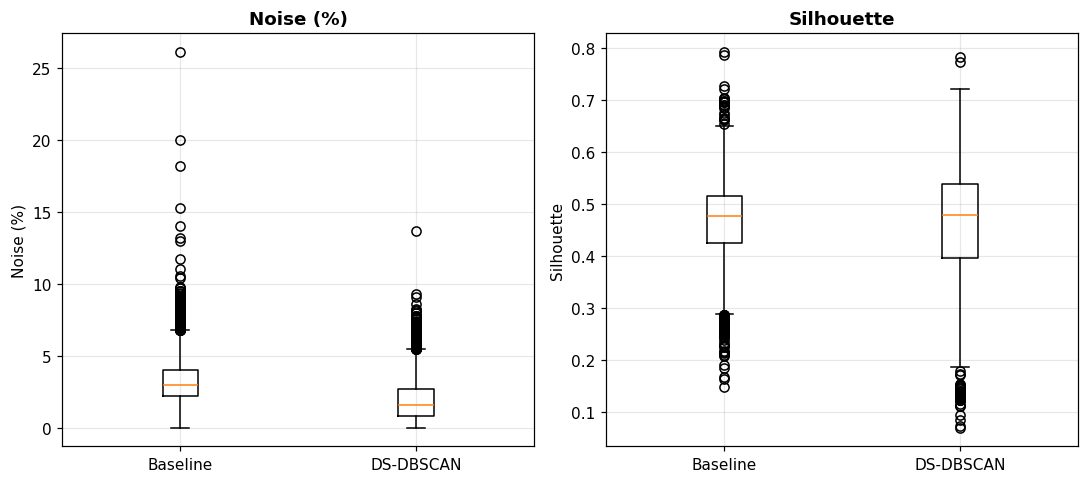

Saved: fig_exp61_real_static.png


In [31]:
panels = [("noise_baseline", "noise_kernel", "Noise (%)"),
          ("silhouette_baseline", "silhouette_kernel", "Silhouette")]
if COMPUTE_ARI and "ari_obj_kernel" in results_df.columns:
    panels.append(("ari_obj_baseline", "ari_obj_kernel", "Obstacle ARI"))

fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 4.5))
if len(panels) == 1: axes = [axes]
for ax, (cb, ck, name) in zip(axes, panels):
    d = results_df[[cb, ck]].dropna()
    ax.boxplot([d[cb], d[ck]], labels=["Baseline", "DS-DBSCAN"])
    ax.set_ylabel(name); ax.set_title(name, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_exp61_real_static.png", bbox_inches="tight")
plt.show()
print("Saved: fig_exp61_real_static.png")


## 8. Export

In [32]:
results_df.to_csv("exp61_results.csv", index=False)
summary.to_csv("exp61_stats.csv", index=False)
print("Saved: exp61_results.csv, exp61_stats.csv\n")
print(f"Noise:      baseline {results_df['noise_baseline'].mean():.1f}%"
      f" -> kernel {results_df['noise_kernel'].mean():.1f}%")
print(f"Silhouette: baseline {results_df['silhouette_baseline'].mean():.3f}"
      f" -> kernel {results_df['silhouette_kernel'].mean():.3f}")
if COMPUTE_ARI and "ari_obj_kernel" in results_df.columns:
    print(f"Obstacle ARI: baseline {results_df['ari_obj_baseline'].mean():.3f}"
          f" -> kernel {results_df['ari_obj_kernel'].mean():.3f}")


Saved: exp61_results.csv, exp61_stats.csv

Noise:      baseline 3.2% -> kernel 2.0%
Silhouette: baseline 0.471 -> kernel 0.471


In [33]:
import numpy as np, pandas as pd
from scipy.stats import wilcoxon

# 1) Collapse each file (= one room) to a single value per metric
room = results_df.groupby("session").agg(
    noise_baseline      = ("noise_baseline","mean"),
    noise_kernel        = ("noise_kernel","mean"),
    clusters_baseline   = ("clusters_baseline","mean"),
    clusters_kernel     = ("clusters_kernel","mean"),
    silhouette_baseline = ("silhouette_baseline","mean"),
    silhouette_kernel   = ("silhouette_kernel","mean"),
    db_baseline         = ("db_baseline","mean"),
    db_kernel           = ("db_kernel","mean"),
).reset_index()

n_rooms = len(room)
print(f"Rooms (independent unit) n = {n_rooms}\n")

# 2) Overall mean + paired Wilcoxon at the ROOM level
def row(label, base_col, kern_col, better):
    a = room[base_col].values            # baseline
    b = room[kern_col].values            # kernel
    m = np.isfinite(a) & np.isfinite(b)
    a, b = a[m], b[m]
    try:    _, p = wilcoxon(a, b)
    except Exception: p = np.nan
    return {"Metric": label, "Baseline": np.mean(a), "DS-DBSCAN": np.mean(b),
            "p (Wilcoxon)": p, "n": len(a), "Better": better}

summary = pd.DataFrame([
    row("Noise (%)",       "noise_baseline",      "noise_kernel",      "lower"),
    row("Clusters",        "clusters_baseline",   "clusters_kernel",   "descriptive"),
    row("Silhouette",      "silhouette_baseline", "silhouette_kernel", "higher"),
    row("Davies-Bouldin",  "db_baseline",         "db_kernel",         "lower"),
])

print(summary.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
summary.to_csv("exp2_summary_table.csv", index=False)

# Per-room detail (for your own check / appendix)
print("\nPer-room:")
print(room.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

Rooms (independent unit) n = 9

        Metric  Baseline  DS-DBSCAN  p (Wilcoxon)  n      Better
     Noise (%)     6.830      1.078         0.004  9       lower
      Clusters     8.163      6.823         0.004  9 descriptive
    Silhouette     0.496      0.399         0.383  8      higher
Davies-Bouldin     0.428      0.592         0.016  8       lower

Per-room:
                                session  noise_baseline  noise_kernel  clusters_baseline  clusters_kernel  silhouette_baseline  silhouette_kernel  db_baseline  db_kernel
2025.01.01_LargeRoom_BoxesInLine_03.csv           3.382         1.154              9.339            8.089                0.429              0.444        0.410      0.469
      2025.01.01_LargeRoom_Empty_01.csv           2.433         1.451              9.447            8.462                0.514              0.545        0.439      0.433
      2025.01.01_LargeRoom_Empty_02.csv           3.469         1.485             10.291            8.937                0

## 9. COMPARATION



Room: 2025.03.02_2_room6boxnoise.csv | scan ts=1772624032 | 360 pts | Δθ≈1.00°


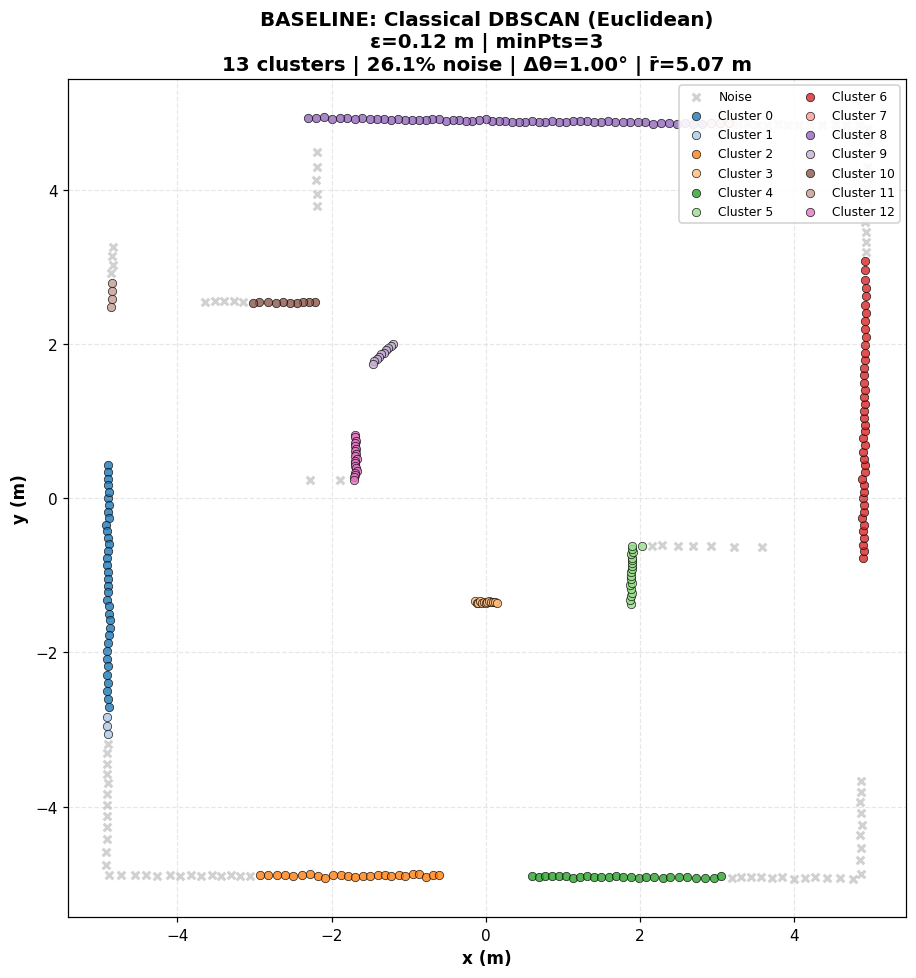

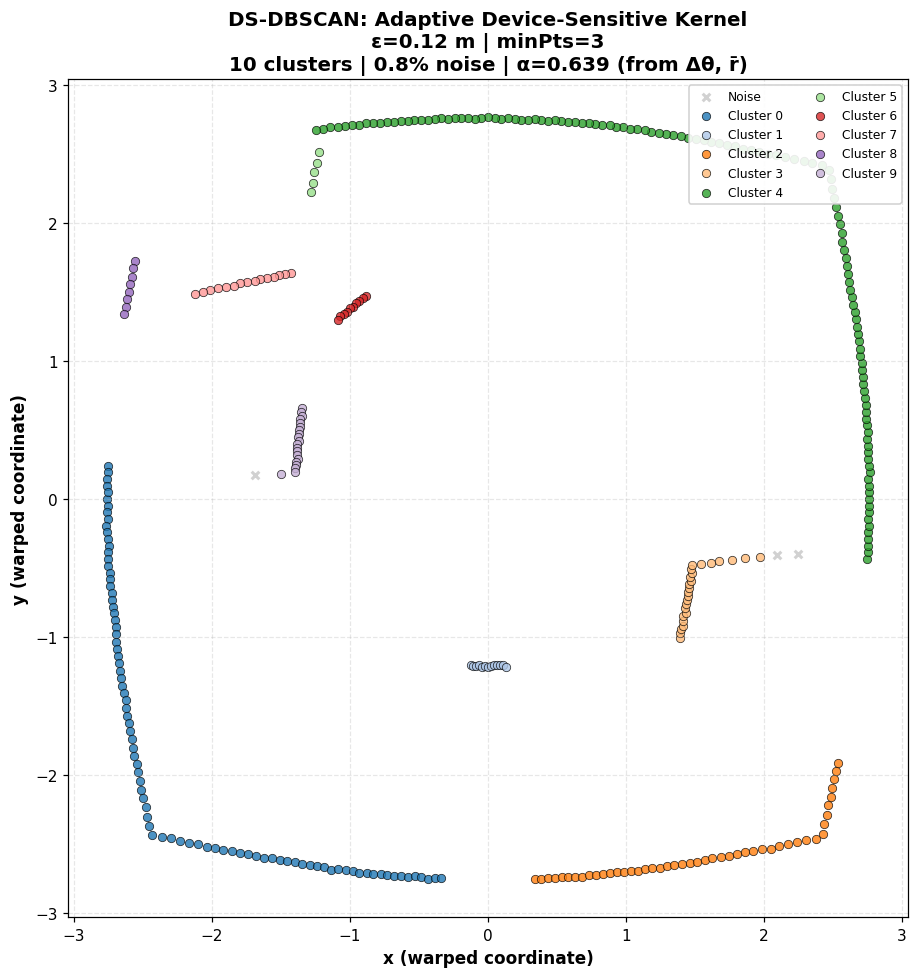


Baseline:  13 clusters, 26.1% noise
DS-DBSCAN: 10 clusters, 0.8% noise (α=0.639)


In [34]:
import numpy as np
import matplotlib.pyplot as plt

# ---- distinct colors + gray for noise ----
def create_enhanced_colormap(n_colors=25):
    base = list(plt.cm.tab20(np.linspace(0, 1, 20)))
    if n_colors > 20:
        base += list(plt.cm.hsv(np.linspace(0, 0.9, n_colors - 20)))
    return base, np.array([0.7, 0.7, 0.7, 1.0])

# ===== CHOOSE THE ROOM (one of your 9 CSV files) =====
ROOM_FILE = "2025.03.02_2_room6boxnoise.csv"   # dramatic example (13→10 clusters)
# =====================================================

sess = pd.read_csv(ROOM_FILE)
sess = sess[np.isfinite(sess["distance_mm"]) & np.isfinite(sess["angle_deg"])]
sess = sess[(sess["distance_mm"] >= MIN_RANGE_MM) & (sess["distance_mm"] <= MAX_RANGE_MM)]

dtheta = estimate_dtheta(sess)
r0 = r0_from_device(S_OBJ_M, dtheta)

# pick the single scan (timestamp) with the most points = most complete sweep
ts = sess.groupby("timestamp").size().idxmax()
df = sess[sess["timestamp"] == ts]
r_bar = df["distance_mm"].median() / 1000.0
print(f"Room: {ROOM_FILE} | scan ts={ts} | {len(df)} pts | Δθ≈{dtheta:.2f}°")

# baseline + kernel
pts_b = prepare_points_euclidean(df)
lab_b = run_dbscan(pts_b)
pts_k, alpha = prepare_points_kernel(df, r_bar, r0)
lab_k = run_dbscan(pts_k)

nb_, nk_   = n_clusters(lab_b), n_clusters(lab_k)
noi_b, noi_k = noise_pct(lab_b), noise_pct(lab_k)
colors, noise_color = create_enhanced_colormap(max(nb_, nk_) + 5)

def plot_one(pts, lab, title, xlab, ylab, fname):
    fig, ax = plt.subplots(figsize=(10, 9))
    nm = lab == -1
    if nm.sum() > 0:
        ax.scatter(pts[nm,0], pts[nm,1], c=[noise_color], s=25, marker='x',
                   linewidths=2, label='Noise', alpha=0.6)
    for cid in sorted(set(lab)):
        if cid == -1: continue
        m = lab == cid
        ax.scatter(pts[m,0], pts[m,1], c=[colors[cid % len(colors)]], s=30,
                   label=f'Cluster {cid}', alpha=0.8, edgecolors='black', linewidth=0.5)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel(xlab, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylab, fontsize=11, fontweight='bold')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='upper right', fontsize=8, ncol=2, framealpha=0.9)
    plt.tight_layout(); plt.savefig(fname, dpi=300, bbox_inches='tight'); plt.show()

plot_one(pts_b, lab_b,
    f'BASELINE: Classical DBSCAN (Euclidean)\nε={FIXED_EPS} m | minPts={FIXED_MIN_SAMPS}\n'
    f'{nb_} clusters | {noi_b:.1f}% noise | Δθ={dtheta:.2f}° | r̄={r_bar:.2f} m',
    'x (m)', 'y (m)', 'exp2_baseline_separate.png')

plot_one(pts_k, lab_k,
    f'DS-DBSCAN: Adaptive Device-Sensitive Kernel\nε={FIXED_EPS} m | minPts={FIXED_MIN_SAMPS}\n'
    f'{nk_} clusters | {noi_k:.1f}% noise | α={alpha:.3f} (from Δθ, r̄)',
    'x (warped coordinate)', 'y (warped coordinate)', 'exp2_kernel_separate.png')

print(f"\nBaseline:  {nb_} clusters, {noi_b:.1f}% noise")
print(f"DS-DBSCAN: {nk_} clusters, {noi_k:.1f}% noise (α={alpha:.3f})")